# Product Category Performance by Region

Two-part look at which product categories perform best and worst, measured by profit margin:

1. **Per-region leaderboard** — best/worst category within each `Order Region`
2. **Volume-weighted overall ranking** — the same categories ranked globally, weighted by each region's sales volume, since a naive average across regions treats a category's showing in a $110K market the same as a $5.9M one

Builds on [`0.2_sales_corr.ipynb`](0.2_sales_corr.ipynb), which established profit margin (`profit / sales`) as the region performance metric.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'  # diverging pair: blue (above-avg margin) <-> red (below-avg margin)
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

# diverging colormap for margin heatmap: red (low) -> neutral gray (mid) -> blue (high)
DIVERGING = LinearSegmentedColormap.from_list('margin_div', [NEG, '#eeece5', POS])

DATA_DIR = '.'

In [2]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
print(f"transactions: {df.shape[0]:,} rows, {df['Order Region'].nunique()} regions, {df['Category Name'].nunique()} categories")

transactions: 180,519 rows, 23 regions, 50 categories


## 0.5 Data-generation artifacts: two exclusions before cross-tabbing

1. **Order-composition break (Oct 2017+, `0.1` §2)**: excluded below, same as every other notebook past `0.1`.
2. **Region-rotation (`0.5_by_region_analysis.ipynb` §2, `0.7_region_activity_gaps.ipynb`)**: 19 of 23 `Order Region`s go permanently dark for months at a time — no region has continuous coverage. That can't be fixed with a row filter, so the region leaderboard below carries a `months_active` column instead: read any region's totals as "per however many months it was actually switched on," not as a full-period comparison.

In [3]:
print(f"rows before exclusion: {len(df):,}")
df = df[df['order date (DateOrders)'] < '2017-10-01'].copy()
print(f"rows after excluding Oct 2017+: {len(df):,}")

rows before exclusion: 180,519
rows after excluding Oct 2017+: 171,962


## 1. Best & worst performing category, by region

Region × category combinations with fewer than 10 order lines are dropped — below that, a single high- or low-profit order swings the margin and the "best" or "worst" label is just noise.

In [4]:
region_cat = df.groupby(['Order Region', 'Category Name']).agg(
    sales=('Sales', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
    n=('Order Id', 'size'),
).reset_index()
region_cat['margin_pct'] = region_cat['profit'] / region_cat['sales'] * 100

rc = region_cat[region_cat['n'] >= 10].copy()
print(f"{len(region_cat)} region x category combos -> {len(rc)} after the n>=10 filter ({len(region_cat) - len(rc)} dropped)")

593 region x category combos -> 511 after the n>=10 filter (82 dropped)


In [5]:
region_sales = df.groupby('Order Region')['Sales'].sum().sort_values(ascending=False)
months_active = df.groupby('Order Region')['order date (DateOrders)'].apply(lambda s: s.dt.to_period('M').nunique())

best = rc.loc[rc.groupby('Order Region')['margin_pct'].idxmax()].set_index('Order Region')
worst = rc.loc[rc.groupby('Order Region')['margin_pct'].idxmin()].set_index('Order Region')

leaderboard = pd.DataFrame({
    'region_sales_m': region_sales / 1e6,
    'months_active': months_active,
    'best_category': best['Category Name'],
    'best_margin_pct': best['margin_pct'],
    'worst_category': worst['Category Name'],
    'worst_margin_pct': worst['margin_pct'],
}).reindex(region_sales.index).round(1)
leaderboard

,region_sales_m,months_active,best_category,best_margin_pct,worst_category,worst_margin_pct
Order Region,,,,,,
Central America,5.7,11,Soccer,24.7,As Seen on TV!,-3.9
Western Europe,5.2,16,Golf Bags & Carts,25.3,Basketball,-10.9
South America,3.0,11,Soccer,23.4,As Seen on TV!,-1.4
Northern Europe,1.9,16,Soccer,25.0,Hockey,-15.8
Southern Europe,1.8,16,Baseball & Softball,22.9,Strength Training,-11.0
Oceania,1.7,7,Hunting & Shooting,24.4,Trade-In,0.2
Caribbean,1.7,11,Boxing & MMA,29.2,Hunting & Shooting,-9.2
West of USA,1.6,5,Golf Shoes,27.2,Golf Apparel,2.8
Southeast Asia,1.5,7,Lacrosse,31.7,Boxing & MMA,1.2


Almost every "best" category above is a low-volume niche within its region ($500–$9K in sales) — a handful of well-timed orders, not a real regional strength. That's the case for volume-weighting made concrete: §2 asks the same question at the category level, weighted by how much each region actually sells.

The heatmap below restricts to the 15 categories with the most total sales, so the pattern is readable across all 23 regions.

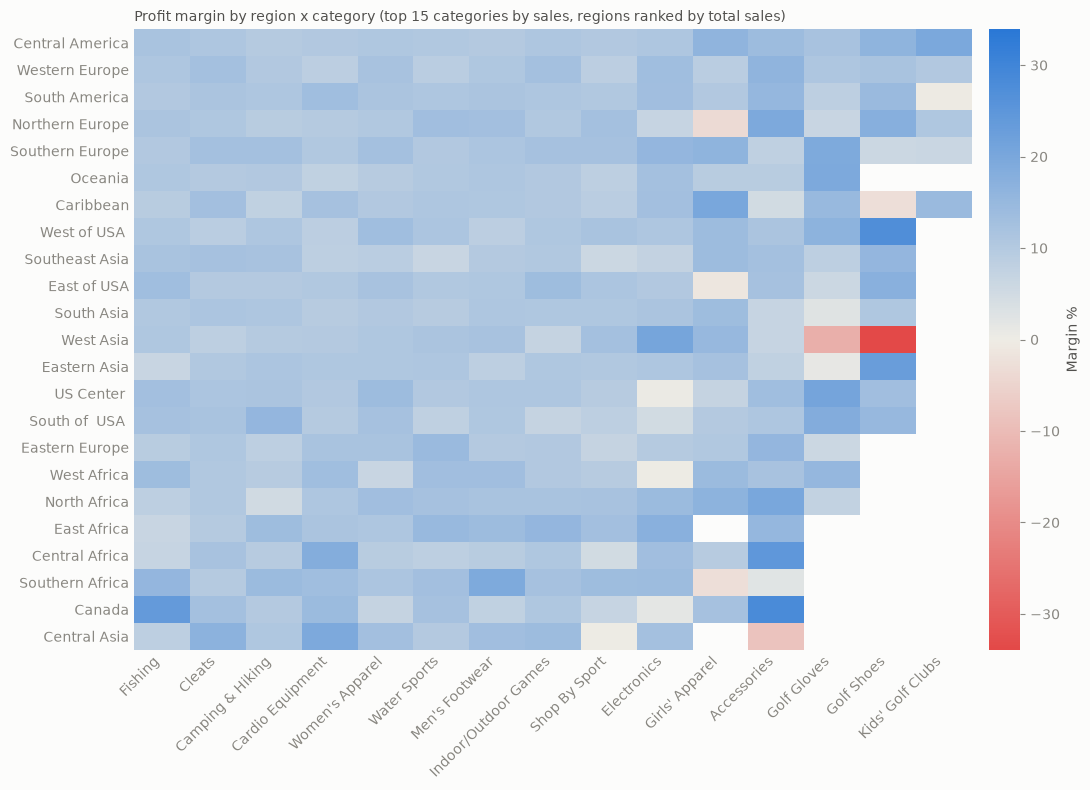

In [6]:
top_categories = df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(15).index.tolist()

pivot = rc[rc['Category Name'].isin(top_categories)].pivot(
    index='Order Region', columns='Category Name', values='margin_pct'
).reindex(index=region_sales.index, columns=top_categories)

fig, ax = plt.subplots(figsize=(11, 8))
vmax = np.nanmax(np.abs(pivot.values))
im = ax.imshow(pivot.values, cmap=DIVERGING, vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.grid(False)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Margin %')
cbar.outline.set_visible(False)

ax.set_title('Profit margin by region x category (top 15 categories by sales, regions ranked by total sales)', loc='left', fontsize=10, color=INK_SECONDARY)
fig.tight_layout()
plt.show()

Blank cells are combos with under 10 order lines. Two things stand out: most columns run in **horizontal stripes of blue** — a category that clears the volume threshold tends to be a healthy margin everywhere it is sold, more of a category-level effect than a region-level one — and the exceptions are the sparse, low-coverage categories (Kids' Golf Clubs, Golf Shoes, Golf Gloves), where a single region's red or dark-blue cell can swing the category's overall read. **Golf Shoes in West Asia** is the clearest example: a single -33.9% margin cell against a column that runs positive (+9% to +27%) everywhere else it's sold.

## 2. Volume-weighted overall ranking

Two ways to roll up each category's regional margins into one number:

- **Naive average** — the mean of `margin_pct` across the regions it appears in, each region counted equally regardless of size
- **Volume-weighted** — total profit / total sales across those same regions, which lets big markets dominate the number the way they dominate the actual P&L

The gap between the two shows which categories only look good (or bad) because of where they happen to sell.

In [7]:
naive = rc.groupby('Category Name')['margin_pct'].mean().rename('naive_mean_margin_pct')
weighted = rc.groupby('Category Name').apply(
    lambda g: g['profit'].sum() / g['sales'].sum() * 100, include_groups=False
).rename('weighted_margin_pct')
total_sales = rc.groupby('Category Name')['sales'].sum().rename('total_sales')
n_regions = rc.groupby('Category Name').size().rename('n_regions')

cmp = pd.concat([naive, weighted, total_sales, n_regions], axis=1)
cmp['delta_pp'] = cmp['weighted_margin_pct'] - cmp['naive_mean_margin_pct']
cmp['naive_rank'] = cmp['naive_mean_margin_pct'].rank(ascending=False).astype(int)
cmp['weighted_rank'] = cmp['weighted_margin_pct'].rank(ascending=False).astype(int)
cmp['rank_shift'] = cmp['naive_rank'] - cmp['weighted_rank']

print(f"{len(cmp)} categories with >=10 order lines in at least one region")
cmp.sort_values('delta_pp')[['naive_mean_margin_pct', 'weighted_margin_pct', 'delta_pp', 'n_regions', 'naive_rank', 'weighted_rank']].round(2).head(5)

32 categories with >=10 order lines in at least one region


,naive_mean_margin_pct,weighted_margin_pct,delta_pp,n_regions,naive_rank,weighted_rank
Category Name,,,,,,
Basketball,-2.42,-7.18,-4.76,2,32,32
Lacrosse,12.91,10.91,-2.00,15,5,18
Men's Golf Clubs,13.17,11.73,-1.44,6,4,8
Cardio Equipment,11.43,10.35,-1.08,23,9,26
Water Sports,10.92,10.45,-0.47,23,18,24


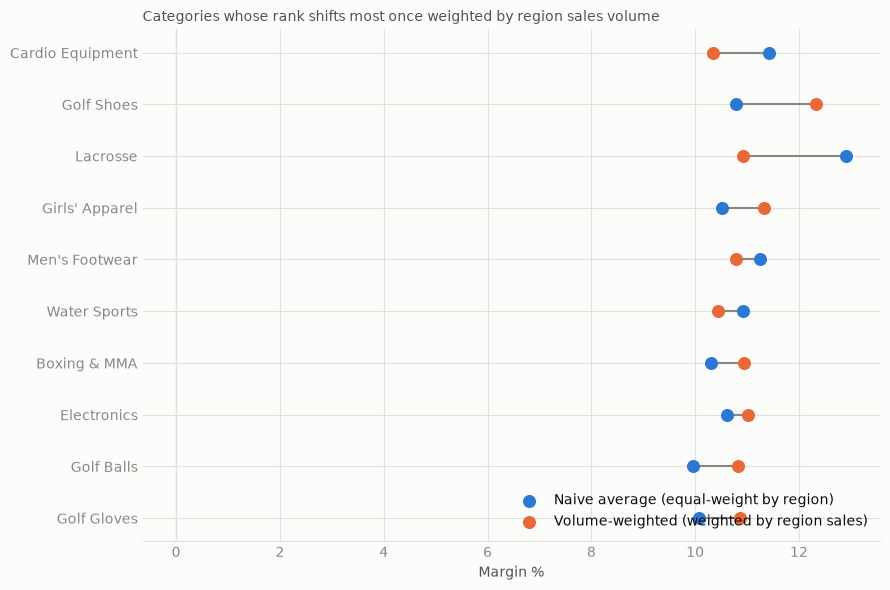

In [8]:
movers = cmp.reindex(cmp['rank_shift'].abs().sort_values(ascending=False).index).head(10)
movers = movers.iloc[::-1]  # largest shift at top of the plot

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(movers))

for yi, (_, row) in zip(y, movers.iterrows()):
    ax.plot([row['naive_mean_margin_pct'], row['weighted_margin_pct']], [yi, yi], color=INK_MUTED, linewidth=1.5, zorder=2)

ax.scatter(movers['naive_mean_margin_pct'], y, color=BLUE, s=70, zorder=3, label='Naive average (equal-weight by region)')
ax.scatter(movers['weighted_margin_pct'], y, color=ORANGE, s=70, zorder=3, label='Volume-weighted (weighted by region sales)')

ax.set_yticks(y)
ax.set_yticklabels(movers.index)
ax.set_xlabel('Margin %')
ax.axvline(0, color=GRID, linewidth=1, zorder=1)
style_axis(ax, x_grid=True, y_grid=False)
ax.legend(loc='lower right', frameon=False)
ax.set_title('Categories whose rank shifts most once weighted by region sales volume', loc='left', fontsize=10, color=INK_SECONDARY)
fig.tight_layout()
plt.show()

Only 32 of the 50 categories clear the 10-order threshold in at least one region here (down from more before the Oct 2017+ exclusion in §0.5 — that window supplied the last few qualifying order lines for several categories, including Computers, Cameras and Crafts, which drop out of this section entirely as a result).

**Lacrosse** is the biggest naive-average casualty: a +12.9% naive average (rank 5 of 32) falls to a weighted +10.9% (rank 18) — it only clears the threshold in 2 of its 15 regions with real volume, and those regions pull the weighted number down. **Basketball** stays dead last either way (naive and weighted rank 32 of 32) — it clears the threshold in just 2 regions and is negative-margin (-2.4% naive, -7.2% weighted) on both counts, not a naive-average illusion.

The reverse happens for **Golf Shoes** (rank 19 → 6) and **Girls' Apparel** (rank 22 → 10): both look mediocre on a naive average but rise sharply once weighted, because their strongest margins land in their higher-volume regions rather than their smaller ones.

**Cardio Equipment** is still the one that matters most for the business: it's sold in all 23 regions (no small-sample issue at all), yet still drops 17 ranks (9 → 26) once weighted — meaning its margin is measurably better in its smaller markets than in its largest ones.

## Takeaways

- **Per-region "best" categories are mostly noise.** In the §1 leaderboard, the top category in almost every region is a low-volume niche (often under $10K in sales) — not a real driver of that region's business.
- **Category margin is largely category-level, not region-level.** The §1 heatmap shows horizontal banding: a category tends to run strong or weak across most regions it's sold in, more than any one region skewing it.
- **Naive cross-region averages overrate thin-coverage categories.** Lacrosse ranks far higher unweighted than weighted (5th → 18th) purely because it's sold in only 2 of its regions at real volume; Basketball ranks last either way, so it isn't a coverage artifact — it's genuinely negative-margin.
- **Cardio Equipment is worth a closer look.** It's sold everywhere (23/23 regions) but still loses 17 ranks (9th → 26th) once weighted by volume — its biggest markets are where it performs worst, which a simple "average margin across regions" metric would never surface.